<a href="https://colab.research.google.com/github/yg36/LangGraph-Learnings/blob/main/Langgraph_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

In [ ]:
class AgentState(TypedDict):
  number1 : int
  number2 : int
  operation : str
  final : int

In [ ]:
def adder(state: AgentState) -> AgentState:
  state['final'] = state['number1'] + state['number2']
  return state

def subtractor(state: AgentState) -> AgentState:
  state['final'] = state['number1'] - state['number2']
  return state

def decide_next_state(state: AgentState) -> AgentState:
  if state['operation'] == '+':
    return "addition_edge"
  elif state['operation'] == '-':
    return "subtract_edge"
  else:
    raise ValueError("Invalid operation")

In [ ]:
graph = StateGraph(AgentState)

graph.add_node("add", adder)
graph.add_node("sub", subtractor)
graph.add_node("decide", lambda state:state)  #passthrough function

graph.add_edge(START, "decide")

graph.add_conditional_edges("decide", decide_next_state,
                            {
                                "addition_edge": "add",
                                "subtract_edge": "sub"
                            })

graph.add_edge("add", END)
graph.add_edge("sub", END)

app = graph.compile()

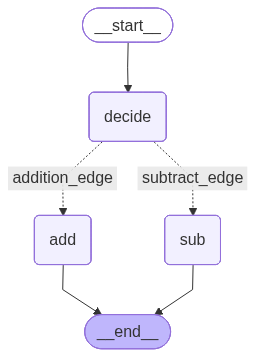

In [ ]:
app

In [ ]:
results = app.invoke({"number1": 10, "number2": 20, "operation": "+"})

In [ ]:
results

{'number1': 10, 'number2': 20, 'operation': '+', 'final': 30}